# Training Face Recognition - Missing Person Detection System

## Using InsightFace (ArcFace ResNet100) - 512-d Embeddings

### Notebook objectives:
1. **Load and inspect images** from the missing person database
2. **Generate face embeddings** (512-d vectors) for each person
3. **Evaluate embedding quality** (intra/inter-person cosine similarity)
4. **Tune recognition threshold** (cosine similarity threshold)
5. **Save embeddings database** for use in the detection pipeline

### Database directory structure:
```
missing_persons_db/
├── person_001/
│   ├── name.txt          # Person's name (e.g. "John Doe")
│   ├── photo1.jpg
│   ├── photo2.jpg
│   └── photo3.jpg
├── person_002/
│   ├── name.txt
│   └── photo1.jpg
└── ...
```

## 1. Setup & Imports

In [1]:
import os
import sys
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
from itertools import combinations
from insightface.app import FaceAnalysis

# Add root directory to path
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
import config
from utils.face_recognizer import FaceRecognizer

# Check environment
print("=== Environment Check ===")
print(f"numpy version: {np.__version__}")
print(f"opencv version: {cv2.__version__}")
print(f"Database dir: {config.MISSING_PERSONS_DB_DIR}")
print(f"Embeddings file: {config.EMBEDDINGS_FILE}")

# Initialize InsightFace
print("\nInitializing InsightFace (ArcFace)...")
app = FaceAnalysis(name=config.INSIGHTFACE_MODEL, providers=["CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))
print("InsightFace ready!")

# Check database directory
if os.path.exists(config.MISSING_PERSONS_DB_DIR):
    person_dirs = [d for d in os.listdir(config.MISSING_PERSONS_DB_DIR)
                   if os.path.isdir(os.path.join(config.MISSING_PERSONS_DB_DIR, d))
                   and d.startswith("person_")]
    print(f"\nFound {len(person_dirs)} person directories in database")
else:
    print(f"\nDatabase directory NOT FOUND!")
    print(f"mkdir -p {config.MISSING_PERSONS_DB_DIR}/person_001")

=== Environment Check ===
numpy version: 2.4.4
opencv version: 4.13.0
Database dir: c:\Users\aa\Desktop\my_project\MissingPersonDetection\missing_persons_db
Embeddings file: c:\Users\aa\Desktop\my_project\MissingPersonDetection\missing_persons_db\embeddings.pkl

Initializing InsightFace (ArcFace)...
download_path: C:\Users\aa/.insightface\models\buffalo_l


100%|██████████| 281857/281857 [00:26<00:00, 10697.96KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\aa/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\aa/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\aa/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\aa/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\aa/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det

## 2. Load and Display Images from Database

Total persons in database: 4

  person_001: Morgan Freeman (3 images)
  person_002: Keanu Reeves (3 images)
  person_003: Scarlett Johansson (3 images)
  person_004: Big Dao (3 images)


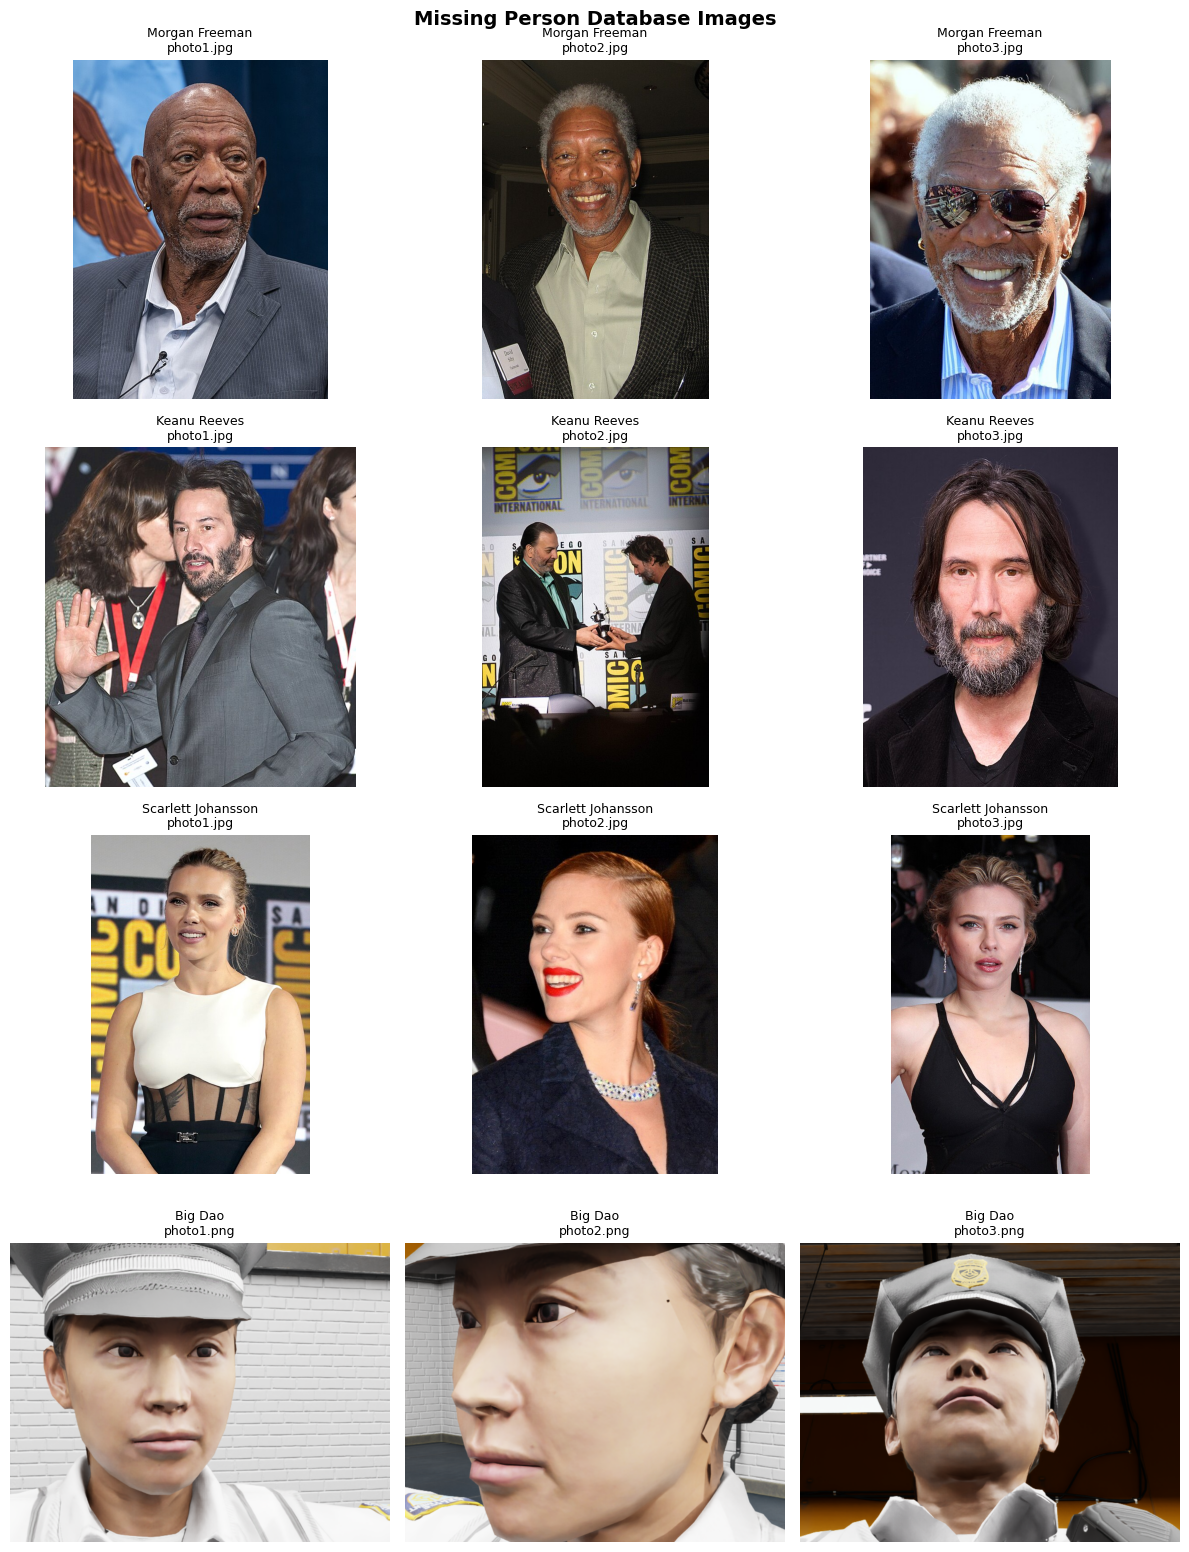

In [2]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def load_person_data(db_dir):
    """Load all person data from database directory."""
    persons = []
    person_dirs = sorted([
        d for d in os.listdir(db_dir)
        if os.path.isdir(os.path.join(db_dir, d)) and d.startswith("person_")
    ])

    for person_dir in person_dirs:
        person_path = os.path.join(db_dir, person_dir)

        # Read name
        name_file = os.path.join(person_path, "name.txt")
        if os.path.exists(name_file):
            with open(name_file, "r", encoding="utf-8") as f:
                name = f.read().strip()
        else:
            name = person_dir

        # Get image list
        image_files = sorted([
            os.path.join(person_path, f)
            for f in os.listdir(person_path)
            if os.path.splitext(f)[1].lower() in IMAGE_EXTENSIONS
        ])

        persons.append({
            "person_id": person_dir,
            "name": name,
            "image_files": image_files,
            "dir": person_path
        })

    return persons

# Load data
persons_data = load_person_data(config.MISSING_PERSONS_DB_DIR)

print(f"Total persons in database: {len(persons_data)}\n")
for p in persons_data:
    print(f"  {p['person_id']}: {p['name']} ({len(p['image_files'])} images)")

# Display sample images
if persons_data:
    max_cols = min(5, max(len(p["image_files"]) for p in persons_data) if persons_data else 1)
    fig, axes = plt.subplots(len(persons_data), max_cols,
                              figsize=(4 * max_cols, 4 * len(persons_data)),
                              squeeze=False)

    for i, person in enumerate(persons_data):
        for j in range(max_cols):
            ax = axes[i][j]
            if j < len(person["image_files"]):
                img = cv2.imread(person["image_files"][j])
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
                ax.set_title(f"{person['name']}\n{os.path.basename(person['image_files'][j])}", fontsize=9)
            ax.axis("off")

    plt.suptitle("Missing Person Database Images", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("\nDatabase is empty! Add images to missing_persons_db/")

## 3. Generate Face Embeddings (ArcFace 512-d)

Using InsightFace ArcFace ResNet100 to generate 512-d vectors for each face.
- Pre-trained on MS1MV2 (~5.8M images, 85K identities)
- More accurate than dlib 128-d (LFW: 99.77% vs 99.38%)

In [3]:
def generate_embeddings(persons_data, face_app):
    """Generate face embeddings for all persons in the database."""
    database = []

    for person in persons_data:
        print(f"\n{'='*50}")
        print(f"[{person['person_id']}] {person['name']}")
        print(f"{'='*50}")

        embeddings = []
        failed_images = []

        for img_path in person["image_files"]:
            img_name = os.path.basename(img_path)
            print(f"  Processing: {img_name}...", end=" ")

            image = cv2.imread(img_path)
            if image is None:
                print("CANNOT READ IMAGE!")
                failed_images.append(img_name)
                continue

            faces = face_app.get(image)

            if len(faces) == 0:
                print("No face found!")
                failed_images.append(img_name)
                continue

            if len(faces) > 1:
                print(f"Found {len(faces)} faces, using largest...", end=" ")
                areas = [(f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]) for f in faces]
                best_face = faces[np.argmax(areas)]
            else:
                best_face = faces[0]

            embeddings.append(best_face.embedding)
            print(f"OK (embedding shape: {best_face.embedding.shape}, "
                  f"det_score: {best_face.det_score:.3f})")

        print(f"\n  Result: {len(embeddings)}/{len(person['image_files'])} images succeeded")
        if failed_images:
            print(f"  Failed: {failed_images}")

        if embeddings:
            database.append({
                "person_id": person["person_id"],
                "name": person["name"],
                "embeddings": embeddings,
                "failed_images": failed_images
            })
        else:
            print(f"  NO EMBEDDINGS for {person['name']}!")

    return database

# Generate embeddings
print("Starting embedding generation...\n")
database = generate_embeddings(persons_data, app)

# Summary
total_embeddings = sum(len(p["embeddings"]) for p in database)
print(f"\n{'='*50}")
print(f"SUMMARY: {len(database)} persons, {total_embeddings} embeddings")
print(f"{'='*50}")

Starting embedding generation...


[person_001] Morgan Freeman
  Processing: photo1.jpg... 

OK (embedding shape: (512,), det_score: 0.834)
  Processing: photo2.jpg... OK (embedding shape: (512,), det_score: 0.834)
  Processing: photo3.jpg... OK (embedding shape: (512,), det_score: 0.814)

  Result: 3/3 images succeeded

[person_002] Keanu Reeves
  Processing: photo1.jpg... OK (embedding shape: (512,), det_score: 0.833)
  Processing: photo2.jpg... Found 2 faces, using largest... OK (embedding shape: (512,), det_score: 0.852)
  Processing: photo3.jpg... OK (embedding shape: (512,), det_score: 0.789)

  Result: 3/3 images succeeded

[person_003] Scarlett Johansson
  Processing: photo1.jpg... OK (embedding shape: (512,), det_score: 0.848)
  Processing: photo2.jpg... OK (embedding shape: (512,), det_score: 0.849)
  Processing: photo3.jpg... OK (embedding shape: (512,), det_score: 0.832)

  Result: 3/3 images succeeded

[person_004] Big Dao
  Processing: photo1.png... OK (embedding shape: (512,), det_score: 0.825)
  Processing: photo2.png... No face found!
  Processing: photo3.png.

## 4. Evaluate Embedding Quality

- **Intra-person similarity**: Cosine similarity between images of the SAME person (should be high, > 0.5)
- **Inter-person similarity**: Cosine similarity between DIFFERENT persons (should be low, < 0.3)

=== EMBEDDING QUALITY EVALUATION ===

--- Intra-person Cosine Similarity (same person, should be > 0.5) ---
  [OK] Morgan Freeman: avg=0.552, min=0.465 (3 pairs)
  [WARNING] Keanu Reeves: avg=0.245, min=0.038 (3 pairs)
  [OK] Scarlett Johansson: avg=0.643, min=0.616 (3 pairs)
  [OK] Big Dao: avg=0.526, min=0.526 (1 pairs)

--- Inter-person Cosine Similarity (different persons, should be < 0.3) ---
  [OK] Morgan Freeman vs Keanu Reeves: avg=-0.007, max=0.048
  [OK] Morgan Freeman vs Scarlett Johansson: avg=-0.005, max=0.046
  [OK] Morgan Freeman vs Big Dao: avg=-0.060, max=-0.045
  [OK] Keanu Reeves vs Scarlett Johansson: avg=-0.028, max=0.035
  [OK] Keanu Reeves vs Big Dao: avg=0.033, max=0.082
  [OK] Scarlett Johansson vs Big Dao: avg=0.016, max=0.085

--- SUMMARY ---
  Intra-person: mean=0.485, min=0.038
  Inter-person: mean=-0.010, max=0.085
  [WARNING] OVERLAP: -0.047 (may cause mismatches)


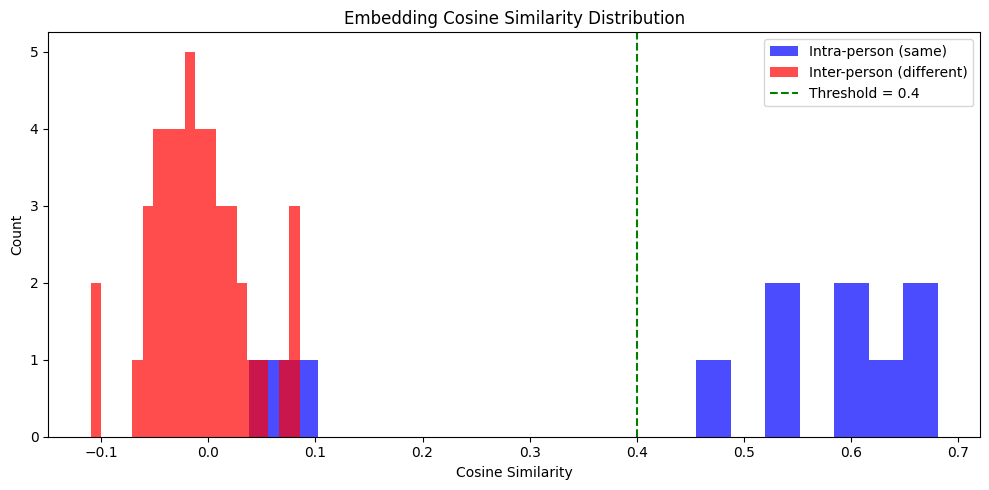

In [4]:
def cosine_similarity(emb1, emb2):
    """Compute cosine similarity between two embeddings."""
    return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

def evaluate_embeddings(database):
    """Evaluate embedding quality using intra/inter-person cosine similarity."""

    if len(database) < 1:
        print("Need at least 1 person in database to evaluate!")
        return None, None

    print("=== EMBEDDING QUALITY EVALUATION ===\n")

    # 1. Intra-person similarities (same person)
    print("--- Intra-person Cosine Similarity (same person, should be > 0.5) ---")
    intra_sims = []
    for person in database:
        encs = person["embeddings"]
        if len(encs) < 2:
            print(f"  {person['name']}: Only 1 image, cannot compute intra-similarity")
            continue

        person_sims = []
        for (enc1, enc2) in combinations(encs, 2):
            sim = cosine_similarity(enc1, enc2)
            person_sims.append(sim)
            intra_sims.append(sim)

        avg = np.mean(person_sims)
        min_s = np.min(person_sims)
        status = "OK" if avg > 0.5 else "WARNING"
        print(f"  [{status}] {person['name']}: avg={avg:.3f}, min={min_s:.3f} ({len(person_sims)} pairs)")

    # 2. Inter-person similarities (different persons)
    print(f"\n--- Inter-person Cosine Similarity (different persons, should be < 0.3) ---")
    inter_sims = []
    if len(database) >= 2:
        for (p1, p2) in combinations(database, 2):
            pair_sims = []
            for enc1 in p1["embeddings"]:
                for enc2 in p2["embeddings"]:
                    sim = cosine_similarity(enc1, enc2)
                    pair_sims.append(sim)
                    inter_sims.append(sim)

            avg = np.mean(pair_sims)
            max_s = np.max(pair_sims)
            status = "OK" if max_s < 0.3 else "WARNING"
            print(f"  [{status}] {p1['name']} vs {p2['name']}: avg={avg:.3f}, max={max_s:.3f}")
    else:
        print("  Need >= 2 persons for inter-person similarity")

    # 3. Summary
    print(f"\n--- SUMMARY ---")
    if intra_sims:
        print(f"  Intra-person: mean={np.mean(intra_sims):.3f}, min={np.min(intra_sims):.3f}")
    if inter_sims:
        print(f"  Inter-person: mean={np.mean(inter_sims):.3f}, max={np.max(inter_sims):.3f}")

    if intra_sims and inter_sims:
        gap = np.min(intra_sims) - np.max(inter_sims)
        if gap > 0:
            print(f"  [OK] Separation gap: {gap:.3f} (good)")
        else:
            print(f"  [WARNING] OVERLAP: {gap:.3f} (may cause mismatches)")

    # Plot distribution
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    if intra_sims:
        ax.hist(intra_sims, bins=20, alpha=0.7, label="Intra-person (same)", color="blue")
    if inter_sims:
        ax.hist(inter_sims, bins=20, alpha=0.7, label="Inter-person (different)", color="red")
    ax.axvline(x=config.RECOGNITION_THRESHOLD, color="green", linestyle="--",
               label=f"Threshold = {config.RECOGNITION_THRESHOLD}")
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Count")
    ax.set_title("Embedding Cosine Similarity Distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return intra_sims, inter_sims

eval_results = evaluate_embeddings(database)

## 5. Tune Recognition Threshold

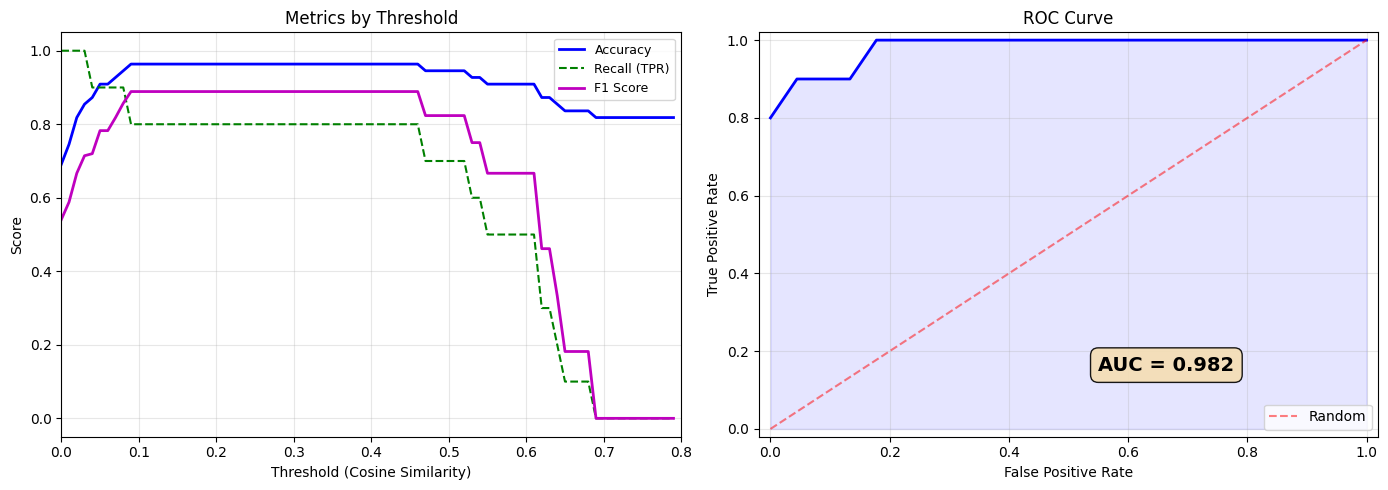


OPTIMAL THRESHOLD: 0.20
  F1 Score:  0.889
  Recall:    0.800
  Accuracy:  96.4%
  AUC:       0.982

Config threshold: 0.4


In [5]:
def find_optimal_threshold(intra_sims, inter_sims):
    """Find the optimal cosine similarity threshold.
    
    Uses F1 score as the optimization criterion with a minimum threshold
    floor of 0.2 to avoid impractically low values.
    """
    if not intra_sims or not inter_sims:
        print("Need both intra and inter similarities to find optimal threshold.")
        print(f"Using default threshold: {config.RECOGNITION_THRESHOLD}")
        return config.RECOGNITION_THRESHOLD

    THRESHOLD_FLOOR = 0.2
    intra_arr = np.array(intra_sims)
    inter_arr = np.array(inter_sims)

    # Threshold sweep (practical range)
    thresholds = np.arange(0.0, 0.80, 0.01)
    best_threshold = config.RECOGNITION_THRESHOLD
    best_f1 = 0

    results_list = []
    for thresh in thresholds:
        tp = np.sum(intra_arr >= thresh); fn = len(intra_sims) - tp
        tn = np.sum(inter_arr < thresh); fp = len(inter_sims) - tn
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
        f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
        results_list.append({
            "threshold": thresh, "accuracy": accuracy,
            "tpr": tpr, "fpr": fpr, "f1": f1
        })
        if thresh >= THRESHOLD_FLOOR and f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

    # === LEFT PLOT: Metrics by Threshold ===
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ts = [r["threshold"] for r in results_list]
    ax1.plot(ts, [r["accuracy"] for r in results_list], "b-", label="Accuracy", linewidth=2)
    ax1.plot(ts, [r["tpr"] for r in results_list], "g--", label="Recall (TPR)", linewidth=1.5)
    ax1.plot(ts, [r["f1"] for r in results_list], "m-", label="F1 Score", linewidth=2)
    ax1.set_xlabel("Threshold (Cosine Similarity)")
    ax1.set_ylabel("Score")
    ax1.set_title("Metrics by Threshold")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.0, 0.8)
    ax1.set_ylim(-0.05, 1.05)

    # === RIGHT PLOT: ROC Curve ===
    # Sweep thresholds HIGH to LOW so FPR increases monotonically
    roc_thresholds = np.arange(0.8, -0.15, -0.01)
    roc_fprs, roc_tprs = [0.0], [0.0]

    for thresh in roc_thresholds:
        tp = np.sum(intra_arr >= thresh); fn = len(intra_sims) - tp
        tn = np.sum(inter_arr < thresh); fp = len(inter_sims) - tn
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        if fpr >= roc_fprs[-1]:
            if fpr == roc_fprs[-1]:
                roc_tprs[-1] = max(roc_tprs[-1], tpr)
            else:
                roc_fprs.append(fpr)
                roc_tprs.append(tpr)

    if roc_fprs[-1] < 1.0:
        roc_fprs.append(1.0)
        roc_tprs.append(1.0)

    auc = np.trapezoid(roc_tprs, roc_fprs)

    ax2.plot(roc_fprs, roc_tprs, "b-", linewidth=2)
    ax2.fill_between(roc_fprs, roc_tprs, alpha=0.1, color="blue")
    ax2.plot([0, 1], [0, 1], "r--", alpha=0.5, label="Random")
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.set_title("ROC Curve")
    ax2.text(0.55, 0.15, f"AUC = {auc:.3f}", fontsize=14, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.9))
    ax2.legend(loc="lower right")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_ylim(-0.02, 1.02)

    plt.tight_layout()
    plt.show()

    best_result = next(r for r in results_list if abs(r["threshold"] - best_threshold) < 0.005)

    print(f"\n{'='*50}")
    print(f"OPTIMAL THRESHOLD: {best_threshold:.2f}")
    print(f"  F1 Score:  {best_result['f1']:.3f}")
    print(f"  Recall:    {best_result['tpr']:.3f}")
    print(f"  Accuracy:  {best_result['accuracy']:.1%}")
    print(f"  AUC:       {auc:.3f}")
    print(f"\nConfig threshold: {config.RECOGNITION_THRESHOLD}")
    print(f"{'='*50}")

    return best_threshold

if eval_results and eval_results[0] is not None:
    intra_sims, inter_sims = eval_results
    optimal_threshold = find_optimal_threshold(intra_sims, inter_sims)
else:
    print("No evaluation data available. Using default threshold.")
    optimal_threshold = config.RECOGNITION_THRESHOLD

## 6. Save Embeddings Database

In [6]:
# Prepare database for saving
save_database = []
for person in database:
    save_database.append({
        "person_id": person["person_id"],
        "name": person["name"],
        "embeddings": person["embeddings"]
    })

# Save pickle file
output_path = config.EMBEDDINGS_FILE
with open(output_path, "wb") as f:
    pickle.dump(save_database, f)

# Confirm
file_size = os.path.getsize(output_path) / 1024  # KB
print(f"Embeddings database saved!")
print(f"   File: {output_path}")
print(f"   Size: {file_size:.1f} KB")
print(f"   Persons: {len(save_database)}")
print(f"   Total embeddings: {sum(len(p['embeddings']) for p in save_database)}")
print(f"\nYou can now run:")
print(f"   python detect_missing_person.py --video path/to/video.mp4")

Embeddings database saved!
   File: c:\Users\aa\Desktop\my_project\MissingPersonDetection\missing_persons_db\embeddings.pkl
   Size: 22.7 KB
   Persons: 4
   Total embeddings: 11

You can now run:
   python detect_missing_person.py --video path/to/video.mp4


## 7. Quick Test with a New Image

In [7]:
# === Test recognition with a new image ===
# Change the test image path here:
TEST_IMAGE_PATH = ""  # e.g. "test_images/test1.jpg"

if TEST_IMAGE_PATH and os.path.exists(TEST_IMAGE_PATH):
    test_image = cv2.imread(TEST_IMAGE_PATH)

    # Detect faces
    faces = app.get(test_image)
    print(f"Found {len(faces)} faces in test image")

    # Load database
    recognizer = FaceRecognizer(config.EMBEDDINGS_FILE, threshold=optimal_threshold)

    # Display results
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    img_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    for face in faces:
        x1, y1, x2, y2 = face.bbox.astype(int)
        embedding = face.embedding

        name, similarity, person_id = recognizer.match(embedding)

        color = "red" if name else "gray"
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)

        if name:
            ax.text(x1, y1 - 5, f"MISSING: {name} ({similarity:.0%})",
                    color="red", fontsize=10, fontweight="bold",
                    bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.8))
            print(f"  MATCH: {name} (similarity={similarity:.3f})")
        else:
            ax.text(x1, y1 - 5, f"Unknown (sim={similarity:.2f})",
                    color="gray", fontsize=8)
            print(f"  No match (max similarity={similarity:.3f})")

    ax.axis("off")
    ax.set_title("Recognition Results on Test Image")
    plt.tight_layout()
    plt.show()
else:
    print("No test image specified. Set TEST_IMAGE_PATH above to test.")
    print("Or run the full pipeline:")
    print("  python detect_missing_person.py --video path/to/video.mp4")

No test image specified. Set TEST_IMAGE_PATH above to test.
Or run the full pipeline:
  python detect_missing_person.py --video path/to/video.mp4
